In [1]:
!pip install -U python-dotenv 

from dotenv import load_dotenv
import os

load_dotenv()  # 현재 경로의 .env 파일을 불러와 환경변수로 등록
# api_key = os.getenv("API_KEY_NAME")  # 대부분 라이브러리에서 자동 인식되므로 생략 가능, 필요시 명시적으로 호출


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


True

In [2]:
!pip install -U langgraph langchain langchain-openai langchain-core langchain-experimental


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

In [4]:
# 챗봇이 사용할 상태(State)를 정의합니다.
# 이 상태는 메시지들을 담고 있는 리스트 형태이며,
# Annotated를 사용하여 'add_messages'라는 업데이트 방식을 명시합니다.
# 즉, 상태가 갱신될 때 기존 메시지를 덮어쓰는 것이 아니라, 새 메시지를 리스트에 추가합니다.
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
graph_builder = StateGraph(State)

In [6]:
# LLM 모델 초기화 
from langchain.chat_models import init_chat_model 
llm = init_chat_model("openai:gpt-4.1") 

In [7]:
# 노드 정의: 상태를 받아 새로운 메시지를 생성해 추가합니다.
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
# 노드를 상태 그래프에 등록합니다.
# 첫 번째 인자는 노드의 이름이며, 두 번째 인자는 노드 함수입니다.
graph_builder.add_node("chatbot", chatbot)

In [9]:
# 엣지 정의: 그래프의 시작점에서 chatbot 노드로 흐름을 연결합니다.
graph_builder.add_edge(START, "chatbot")

In [10]:
# 그래프를 컴파일하여 실행 가능한 형태로 변환합니다.
graph = graph_builder.compile()

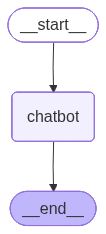

In [11]:
# 그래프 구조를 시각적으로 출력합니다 (선택 사항)
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 시각화를 위해 별도 라이브러리가 필요하며, 없을 경우 무시해도 됩니다.
    pass

In [12]:
# 사용자 입력을 받아 그래프를 실행하고, 응답을 출력하는 함수입니다.
def stream_graph_updates(user_input: str):
    # 'graph.stream()'은 LangGraph를 단계별로 실행하며 중간 결과를 제공합니다.
    for event in graph.stream({
        "messages": [{"role": "user", "content": user_input}]
    }):
        # 각 이벤트에는 노드의 실행 결과가 담겨 있습니다.
        for value in event.values():
            # 가장 마지막 메시지를 꺼내어 출력합니다.
            print("Assistant:", value["messages"][-1].content)

# 챗봇을 반복적으로 사용할 수 있도록 무한 루프를 설정합니다.
while True:
    # 사용자에게 입력을 받습니다.
    user_input = input("User: ")

    # 사용자가 종료 명령을 입력하면 프로그램을 종료합니다.
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    # 입력한 내용을 바탕으로 챗봇 응답을 실행합니다.
    stream_graph_updates(user_input)

Assistant: 안녕하세요! 무엇을 도와드릴까요? 😊
Assistant: 안녕하세요! 저는 OpenAI에서 개발한 인공지능 언어모델, 즉 AI 챗봇입니다. 제가 할 수 있는 일은 매우 다양합니다. 예를 들어:

1. **정보 제공**  
   - 과학, 역사, 기술, 예술 등 다양한 분야의 지식 설명
   - 일반 상식, 최신 연구(2024년 6월까지) 기반 정보 안내

2. **글쓰기 도움**  
   - 에세이, 보고서, 이메일, 자기소개서, 소설, 시 등 다양한 글쓰기 지원
   - 문장 교정, 글 다듬기, 문법 체크

3. **번역**  
   - 영어, 한국어, 일본어, 중국어 등 여러 언어 간 번역

4. **학습 및 공부 도움**  
   - 수학 문제 풀이
   - 개념 설명 및 예제 제공
   - 요약 또는 암기 팁 제공

5. **코딩 및 프로그래밍**  
   - 코드 작성, 오류 진단, 코드 해석 등
   - Python, Java, C, JavaScript 등 다양한 언어 지원

6. **창의적 아이디어 제공**  
   - 마케팅 아이디어 제안
   - 프로젝트, 발표, 창작 아이디어 브레인스토밍

7. **일상 상담**  
   - 진로, 공부, 인간관계 등에 대한 조언 제공  
   (전문 심리상담은 아니지만, 친절하게 도와드릴 수 있습니다)

원하는 것이 무엇이든 말씀해 주세요! 최대한 잘 도와드릴 수 있도록 노력하겠습니다.
Goodbye!
